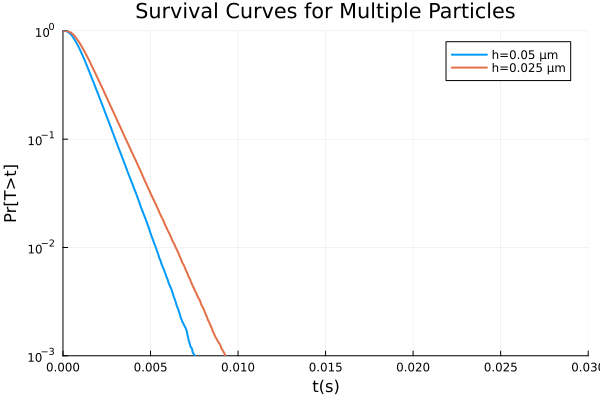

In [1]:
using Random
using Statistics
using Plots



function neighbors(N::Int)
    nbrs = [Tuple{Int, Int}[] for _ in 1:N, _ in 1:N]
    for i in 1:N
        for j in 1:N
            if i > 1
                push!(nbrs[i, j], (i - 1, j))
            end
            if i < N
                push!(nbrs[i, j], (i + 1, j))
            end
            if j > 1
                push!(nbrs[i, j], (i, j - 1))
            end
            if j < N
                push!(nbrs[i, j], (i, j + 1))
            end
        end
    end
    return nbrs
end


function crdme_ssa_multiple_particles_2D_reflecting(
    rng::AbstractRNG;
    L::Float64,
    h::Float64,
    NA0::Int,
    NB0::Int,
    DA::Float64,
    DB::Float64,
    λ::Float64,
    ε::Float64,
    Tfinal::Float64 = Inf
)

    N = Int(ceil(L / h))
    nA = zeros(Int, N, N)
    nB = zeros(Int, N, N)

    for k in 1:NA0
        i = rand(rng, 1:N)
        j = rand(rng, 1:N)
        nA[i, j] += 1
    end
    for k in 1:NB0
        i = rand(rng, 1:N)
        j = rand(rng, 1:N)
        nB[i, j] += 1
    end

    κA = DA / (h*h)
    κB = DB / (h*h)


    t = 0.0
    #Precompute the reaction pair list
    react_pairs = Tuple{Tuple{Int,Int},Tuple{Int,Int},Float64}[]
    ncells = ceil(Int, (ε + h) / h / h)
    for i in 1:N
        for j in 1:N
            center_x_A = (i - 0.5) * h
            center_y_A = (j - 0.5) * h

            x_B_min = max(1, i - ncells)
            x_B_max = min(N, i + ncells)
            y_B_min = max(1, j - ncells)
            y_B_max = min(N, j + ncells)

            for x_B in x_B_min:x_B_max
                for y_B in y_B_min:y_B_max
                    center_x_B = (x_B - 0.5) * h
                    center_y_B = (y_B - 0.5) * h

                    r2 = (center_x_A - center_x_B)^2 + (center_y_A - center_y_B)^2

                    if r2 <= ε^2
                        push!(react_pairs, ((i, j), (x_B, y_B), λ))
                    end
                end
            end
        end
    end

    deg_A = zeros(Int, N, N)
    deg_B = zeros(Int, N, N)

    for i in 1:N
        for j in 1:N
            deg_A[i, j] = 4 - (i == 1) - (i == N) - (j == 1) - (j == N)
            deg_B[i, j] = 4 - (i == 1) - (i == N) - (j == 1) - (j == N)
        end
    end

    nrbs = neighbors(N)


    while t < Tfinal && sum(nA) > 0 && sum(nB) > 0


        R_A = κA * sum(nA .* deg_A)
        R_B = κB * sum(nB .* deg_B)
        R_react = 0.0

        for ((iA, jA), (iB, jB), λ) in react_pairs
            R_react += λ * nA[iA, jA] * nB[iB, jB]
        end
        
        R_total = R_A + R_B + R_react

        t += randexp(rng)/R_total
        if t >= Tfinal
            return Tfinal, false
        end

        r = rand(rng) * R_total

        if r < R_A

            # Compute the cumulative sum of the diffusion rates for A
            Asum = cumsum(vec(deg_A .* nA))

            # Select a random number between 0 and the total diffusion rate for A
            rA = rand(rng) * Asum[end]

            # Search for the voxel index for the diffusion
            k = searchsortedfirst(Asum, rA) 

            idx = CartesianIndices(nA)[k]
            i, j = idx[1], idx[2]
            i_diffusion, j_diffusion = rand(rng, nrbs[i, j])
            nA[i, j] -= 1
            nA[i_diffusion, j_diffusion] += 1
        
        elseif r < R_A + R_B
            # Compute the cumulative sum of the diffusion rates for B
            Bsum = cumsum(vec(deg_B .* nB))

            # Select a random number between 0 and the total diffusion rate for B
            rB = rand(rng) * Bsum[end]

            # Search for the voxel index for the diffusion
            k = searchsortedfirst(Bsum, rB)

            idx = CartesianIndices(nB)[k]
            i, j = idx[1], idx[2]
            i_diffusion, j_diffusion = rand(rng, nrbs[i, j])
            nB[i, j] -= 1
            nB[i_diffusion, j_diffusion] += 1

        else
            
            # Compute the cumulative sum of the reaction rates
            Rsum = cumsum([λ * nA[iA, jA] * nB[iB, jB] for ((iA, jA), (iB, jB), λ) in react_pairs])

            # Select a random number between 0 and the total reaction rate
            rR = rand(rng) * Rsum[end]

            # Search for the reaction pair index
            k = searchsortedfirst(Rsum, rR)

            (iA, jA), (iB, jB), λ = react_pairs[k]
            nA[iA, jA] -= 1
            nB[iB, jB] -= 1
        end
    end

    return t, true
end

function run_multiple_simulations(
    num_sims::Int;
    L::Float64,
    h::Float64,
    NA0::Int,
    NB0::Int,
    DA::Float64,
    DB::Float64,
    λ::Float64,
    ε::Float64,
    Tfinal::Float64 = Inf
)
    Ts = zeros(Float64, num_sims)
    for sim in 1:num_sims
        rng = Xoshiro(sim) # Use a different seed for each simulation
        t, _ = crdme_ssa_multiple_particles_2D_reflecting(
            rng;
            L=L, h=h, NA0=NA0, NB0=NB0, DA=DA, DB=DB, λ=λ, ε=ε, Tfinal=Tfinal
        )
        Ts[sim] = t
    end
    return Ts
end

function survival_curve(Ts::Vector{Float64}, tgrid::AbstractVector{Float64})
    n = length(Ts)
    S = Vector{Float64}(undef, length(tgrid))
    for (i, t) in enumerate(tgrid)
        S[i] = count(x -> x > t, Ts) / n
    end
    return max.(S, 1e-12)
end

function main()
    L = 0.2
    NA0 = 10
    NB0 = 10
    DA = 10.0
    DB = 10.0
    λ = 1e9
    ε = 1e-3
    Tfinal = 0.03
    num_sims = 128_000

    hs = [1e-3/0.02, 1e-3/0.04]
    
    tgrid = range(0, Tfinal, length=1000)

    plt = plot(title="Survival Curves for Multiple Particles", xlabel="t(s)", ylabel="Pr[T>t]", xlim=(0, Tfinal), ylim=(1e-3, 1), yscale=:log10, legend=:topright)

    for (idx, h) in enumerate(hs)
        Ts = run_multiple_simulations(num_sims; L=L, h=h, NA0=NA0, NB0=NB0, DA=DA, DB=DB, λ=λ, ε=ε, Tfinal=Tfinal)
        S = survival_curve(Ts, tgrid)
        mask = S .> 1e-5
        plot!(plt, tgrid[mask], S[mask], label="h=$(h) μm", lw=2)
    end

    display(plt)
end

main()



                  
            



In [6]:
using LinearAlgebra
dims = (3, 4, 2)
index = 3
CartesianIndices(dims)[index] 


CartesianIndex(3, 1, 1)